# 2026/7/30 笔记

<div align="center">

<img src="transformer.png" style="width:30%">

Transformer整体架构  
</div>


<div align="center">

<img src="attention.webp" style="width: 15%;">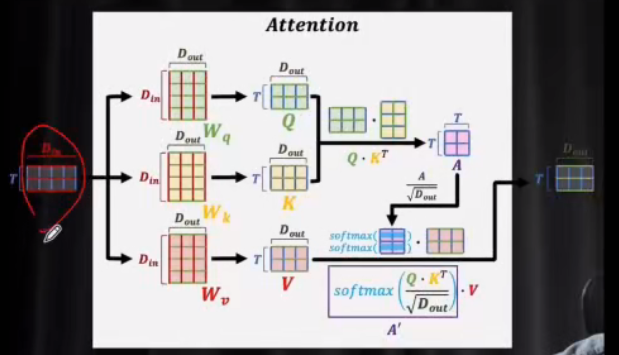 

注意力机制计算过程

</div>  

$$
Attention(Q,K,V)
=
softmax(\frac{QK^T}{\sqrt{d_k}})V  
$$
- attention计算过程中的QKV点乘运算主要目的就是:  
用于计算Query和Key之间的相关性，通过这个相关性得到注意力权重，然后利用权重对Value进行加权求和，  
使当前位置的词向量融合上下文信息。这个过程不是直接改变QKV的方向，而是在新的语义空间中动态调整  
不同词信息的贡献比例，从而生成包含上下文信息的表示。  

- 更好理解**加权求和**：  
<div align="center">
<img src="attention结果.png" style="width:70%;">
</div>

- mask的目的是：  
在生成过程中，永远都是根据现有的token预测下一个token，所以当前位置的 token 只能关注它之前  
已经出现的 token（包括自己），即使前面的token已经生成了也要按照这种规律来进行计算。  
因此mask-attention的结果是一个三角矩阵，其余部分的数值为负无穷，使这部分softmax的结果为0进而  
在对V加权的时候，防止当前位置token获取未来token的信息   

- 除以$\sqrt{d_k}$的目的是：  
向量维数越大，点积的结果也越大，然后进行softmax会导致输出结果很极端，接近one-hot，  
进而导致在对于V进行加权的时候只考虑其中一个token。  
    - 例：d = 64，输入token长度为3，$QK^T$结果：[40, 50, 45]  
        则$Softmax([40, 50, 45])≈[0.00004, 0.993, 0.007]$  
    - $[40, 50, 45]$除以$\sqrt{64}=8$得到$[5, 6.25, 5.6]$，$Softmax([5, 6.25, 5.6])=[0.18,0.64,0.18]$



<div align="center">

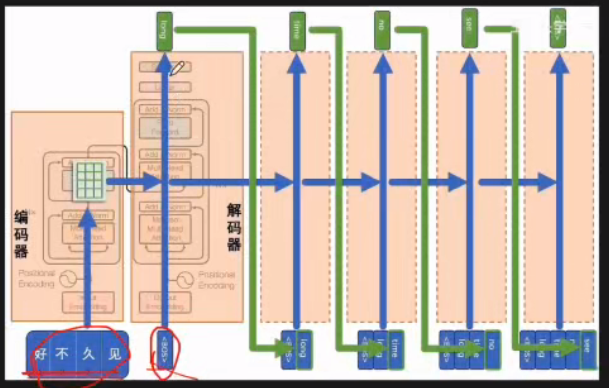

</div>

-  Encoder-Decoder架构常用于机器翻译：
将输入的中文翻译成英文  
encoder部分将中文进行嵌入、编码，再经过不同的映射后作为decoder部分的K、V矩阵（这个做法也比较合理，因为是通过对V矩阵进行加权来得到下面的翻译结果）。  
    - 在解码器部分输入第一个token是`<BOS>`用于表示开始字符  
    - 解码器中先进行自注意力计算，然后与编码器结果进行交叉注意力计算  
    - 每一步预测出的 Token 会作为下一步 Decoder 的输入：`<BOS>` -> `<BOS>` Long -> `<BOS>` Long time -> `<BOS>` Long time no -> `<BOS>` Long time no see

<div style="page-break-after: always;"></div>

# 2026/7/31

- Add & Norm 中使用残差链接的原因：
    - 注意力层或前馈层并不一定总能产生更好的表示，尤其是在网络层数很深的时候注意力层的结果可能起到反效果，  
    因此为了防止经过该层的张量的表征能力变差，于是在此加上原有的张量这样至少能保证原有张量的能力，不会起到反效果。  
    - 关于梯度消失：大模型的层数非常多，梯度回传要经过很多层，最后导致梯度消失。添加残差连接可以使梯度  
    相对直接回传到前面的层，从而使训练相对快速稳定。  
<br>

- LayerNorm 过程：针对每个token，在 hidden_dim 的尺度分别进行**减均值，除方差**操作  
例如残差链接的结果$X$的张量形状为```(batch, seq_len, hidden_dim) -> (1, 4, 5)```，  
代表共有4个token，每个token维度为5。  
    $$ 
    X=
    \begin{bmatrix}
    x_{11}&x_{12}&x_{13}&x_{14}&x_{15}\\
    x_{21}&x_{22}&x_{23}&x_{24}&x_{25}\\
    x_{31}&x_{32}&x_{33}&x_{34}&x_{35}\\
    x_{41}&x_{42}&x_{43}&x_{44}&x_{45}
    \end{bmatrix}
    $$
    均值：
    $$
    \mu=\frac{x_{11}+x_{12}+x_{13}+x_{14}+x_{15}}{5}
    $$
    方差：
    $$
    \sigma^2=\frac{\sum(x_{1i}-\mu)^2}{5}
    $$
    正则化结果：
    $$
    \hat{x_{1i}}=\gamma\cdot\frac{x_{1i}-\mu}{\sqrt{\sigma^2+\epsilon}}+\beta
    $$
    注意：  
    - 沿**隐藏层维度**进行归一化，即对每个 token 独立计算其特征维度的均值和方差，不是在不同 token 之间进行归一化。  
    - LayerNorm也有**可学习的参数**，并不只是单纯数学处理：**$\gamma$ 权重 $\beta$ 偏置**  
    - 每一个维度都有自己的 **$\gamma$ 权重和 $\beta$ 偏置**，所有token都经过这组权重和偏置参数

<br>

- Feed Forward Net(FFN)过程：  
    $$
    FFN(x)=max(0,xW_1+b_1)W_2+b_2
    $$
    $W_1$升维度、$W_2$降维度:  
    $$
    d_{model}=512 \rightarrow d_{ff}=2048 \rightarrow d_{model}=512
    $$
    目的：**引入非线性变换的同时增加特征表示能力**  
<br>

- Dropout细节：  
    - Pytorch中Dropout(0.1)代表将输入张量中随机10%的数值置零
    - 其余数值按照比例放大：  
        $$\frac{1}{1-p}$$
        其中，$p$是dropout概率。这一步的目的是为了保证输出的期望值（平均值）不变。
<br>

多头注意力手撕

In [5]:
import torch
import torch.nn as nn
import math

class ScaledDotProductAttention(nn.Module):
    """
    论文公式: Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V
    纯 PyTorch 原生实现，无第三方封装
    """
    def __init__(self, d_k):
        super().__init__()
        self.d_k = d_k

    def forward(self, q, k, v, mask=None):
        # 1. 计算注意力分数: Q @ K^T
        # q: [batch, heads, seq_len, d_k]
        # k: [batch, heads, seq_len, d_k]
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

        # 2. Mask 处理 (防止信息泄露 / Padding 屏蔽)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # 3. Softmax 归一化
        attn_weights = torch.softmax(scores, dim=-1)

        # 4. 加权求和: attn_weights @ V
        output = torch.matmul(attn_weights, v)
        return output, attn_weights

class MultiHeadAttention(nn.Module):
    """
    多头注意力机制
    论文公式: MultiHead(Q,K,V) = Concat(head_1, ..., head_h) W^O
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # 线性投影层 (W_Q, W_K, W_V, W_O)
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention(self.d_k)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        # 1. 线性投影并分头: [batch, seq, d_model] -> [batch, heads, seq, d_k]
        # 将 d_model 按照注意力头数均分隐藏层维度
        # 转置的目的是让 序列长度 和 隐藏维度数 放在最后两个维度位置上，便于矩阵乘法
        q = self.w_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = self.w_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = self.w_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # 2. 缩放点积注意力
        attn_output, attn_weights = self.attention(q, k, v, mask)

        # 3. 多头拼接 + 最终线性投影
        # [batch, heads, seq, d_k] -> [batch, seq, d_model]
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.w_o(attn_output)

        return output, attn_weights

# --- 验证代码 (他可以直接跑这段来测试) ---
if __name__ == "__main__":
    # 模拟输入: batch=2, seq_len=5, d_model=64, heads=8
    batch_size, seq_len, d_model, num_heads = 2, 5, 64, 8
    d_k = d_model // num_heads

    # 随机生成 Q, K, V
    query = torch.randn(batch_size, seq_len, d_model)
    key = torch.randn(batch_size, seq_len, d_model)
    value = torch.randn(batch_size, seq_len, d_model)

    # 初始化多头注意力
    mha = MultiHeadAttention(d_model, num_heads)

    # 计算掩码矩阵
    # tril生成下三角矩阵
    mask = torch.tril(torch.ones(seq_len, seq_len))
    
    # 前向传播
    output, weights = mha(query, key, value, mask)

    print(f"输入维度: {query.shape}")
    print(f"输出维度: {output.shape}")  # 应为 [2, 5, 64]
    print(f"注意力权重维度: {weights.shape}")  # 应为 [2, 8, 5, 5]
    print("✅ 核心公式验证通过，维度对齐无误")

输入维度: torch.Size([2, 5, 64])
输出维度: torch.Size([2, 5, 64])
注意力权重维度: torch.Size([2, 8, 5, 5])
✅ 核心公式验证通过，维度对齐无误


TransformerEncoder手撕

In [12]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dim_feedforward, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_output, _ = self.self_attn(x, x, x, mask)
        
        x = self.norm1(self.dropout(attn_output) + x)

        ffn_output = self.feed_forward(x)
        x = self.norm2(self.dropout(ffn_output) + x)

        return x

# 验证代码
if __name__ == "__main__":
    d_model, num_heads, dim_feedforward = 64, 8, 256

    enclayer = EncoderLayer(d_model, num_heads, dim_feedforward)
    x = torch.randn(2, 5, d_model)

    out = enclayer(x)
    assert out.shape == x.shape, "EncoderLayer 输出维度必须与输入一致"
    print(f"✅ EncoderLayer 维度验证通过")

✅ EncoderLayer 维度验证通过


<div style="page-break-after: always;"></div>

# 2026/8/1
- 绝对位置编码(Absolute Position Encoding, APE):  
    - 注意力机制只负责考虑token之间的相关性，没有考虑到token出现顺序的问题，会产生“你爱我”和“我爱你”在  
    模型眼中是一个意思的现象。因此需要给每个token引入句中位置信息  
    - 论文原文设计了一组数学公式：
        token偶数维度：  
        $$PE(pos,2i)=\sin\left(\frac{pos}{10000^{2i/d}}\right)$$
        token奇数维度：  
        $$PE(pos,2i+1)=\cos\left(\frac{pos}{10000^{2i/d}}\right)$$
        其中，pos：位置；i：维度编号；d：embedding维度

In [15]:
import math

# 对数运算表达式的用法 
x = 100
base = 10
res = math.log(x, base)
print(res)

# 默认情况下，底数为e
res1 = math.log(math.e)
print(res1)

# 预制的以10为底的函数
res2 = math.log10(x)
print(res2)

dim_list = torch.arange(0, d_model, 2).float()
dev_term = torch.exp(-math.log(10000) / d_model * dim_list)

2.0
1.0
2.0


- 手撕绝对位置编码  
    - 编程细节：  
        因为位置编码矩阵数值是固定的所以在类初始化的时候就已经生成了位置编码矩阵，  
        而不是每次输入新的张量的时候都重新调用一遍方法  
    - 指数计算部分有点绕，主要就是用维度编号矩阵($2i$)去做乘法

In [17]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(
            0,
            max_len,
            dtype=torch.float
        ).unsqueeze(1)


        # torch.exp 支持张量运算 
        div_term = torch.exp(
            torch.arange(0,d_model,2).float()
            *
            (-math.log(10000.0)/d_model)
        )


        pe[:,0::2] = torch.sin(
            position * div_term
        )

        pe[:,1::2] = torch.cos(
            position * div_term
        )


        # 增加batch维
        pe = pe.unsqueeze(0)

        # 注册buffer，不参与训练
        self.register_buffer(
            "pe",
            pe
        )


    def forward(self,x):

        seq_len = x.size(1)

        return x + self.pe[:,:seq_len]

bpe = PositionalEncoding(d_model=512, max_len=128)
batch_size = 32
seq_len = 5
d_model = 512
x = torch.randn(batch_size, seq_len, d_model)

x = bpe(x)
print(x.shape)


torch.Size([32, 5, 512])


<div style="page-break-after: always;"></div>

# 2026/8/3
### 旋转位置编码

- 旋转位置编码(RoPE, Rotary Position Embedding)

  - 绝对位置编码将位置信息加到 token 的 embedding 向量上；RoPE 则对注意力中的 $Q$ 和 $K$ 进行旋转，使它们的内积包含相对位置信息。

  <div align="center">
    <img src="旋转矩阵推导.jpg" width="40%">
    <br>
    旋转矩阵推导
  </div>

  - 对于位置为 $m$ 的 token，在第 $i$ 个**二维子空间**中（注意这里与绝对位置编码中的维度数 $i$ 不同），实际旋转角为：

  $$
  m\theta_i
  $$

  - 第 $i$ 个二维子空间的基础旋转频率为：

  $$
  \theta_i = \frac{1}{10000^{\frac{2i}{d}}}
  $$

  - 因而，该子空间的旋转矩阵为：

    $$
    R_i(m) =
    \begin{bmatrix}
    \cos(m\theta_i) & -\sin(m\theta_i) \\
    \sin(m\theta_i) & \cos(m\theta_i)
    \end{bmatrix}
    $$
  
    注意这里可以发现，后面解释相对位置的时候会用到：
  
    $$
    R_i(m)^T = R_i(-m)
    $$

  - 对 $d$ 维向量进行旋转，假设：
  
    $$
    q=[q_0,q_1,q_2,q_3,...,q_{d-2},q_{d-1}]
    $$
  
    两个相邻的维度作为一组，运算时偶数维度和它下一个也就是奇数维度进行计算：
  
    $$
    (q_0,q_1)
    (q_2,q_3)
    ...
    (q_{d-2},q_{d-1})
    $$
  
    每一组使用不同的频率：
  
    $$
    \theta_0,\theta_1,...,\theta_{d/2-1}
    $$
    
    第 $2i,2i+1$维：
    $$
    \begin{bmatrix}
    q'_{2i}\\
    q'_{2i+1}
    \end{bmatrix}
    =
    \begin{bmatrix}
    \cos(m\theta_i)&-\sin(m\theta_i)\\
    \sin(m\theta_i)&\cos(m\theta_i)
    \end{bmatrix}
    \begin{bmatrix}
    q_{2i}\\
    q_{2i+1}
    \end{bmatrix}
    $$

  - 写成大矩阵形式：

    $$
    R(m)=
    \begin{bmatrix}
    R_0(m)&0&...&0\\
    0&R_1(m)&...&0\\
    ...&&&\\
    0&0&...&R_{d/2-1}(m)
    \end{bmatrix}
    $$

    其中：
    $$
    R_i(m)=
    \begin{bmatrix}
    \cos(m\theta_i)&-\sin(m\theta_i)\\
    \sin(m\theta_i)&\cos(m\theta_i)
    \end{bmatrix}
    $$

  - 相对位置的引入，解释 $R(n-m)$ 的由来：

    这里的 $q, k$ 都是**列向量**，因为旋转矩阵左乘列向量进行旋转
    
    对于位置 $m$ 的Query：

    $$
    q_m'=R(m)q_m
    $$

    对于位置 $n$ 的Key：

    $$
    k_n'=R(n)k_n
    $$

    两者Attention分数：
    $$
    QK^T = \begin{bmatrix}
    q_1^T\\
    q_2^T\\
    q_3^T
    \end{bmatrix}
    \begin{bmatrix}
    k_1&k_2&k_3
    \end{bmatrix}
    $$

    $$
    (q_m')^Tk_n'=(R(m)q_m)^T(R(n)k_n)=(q_m)^TR(m)^TR(n)k_n
    $$

    有 $R(m)^T=R(-m)$ ，因此：

    $$
    (q_m')^Tk_n'=(q_m)^TR(n-m)k_n
    $$

    计算后仍然是一个标量

    RoPE 将相对位置信息**编码进 Query-Key 的内积计算**中，使 Attention score **不仅依赖 token 内容，还依赖两个 token 的相对距离**。

补：当时一直不明白无论是绝对位置编码还是旋转位置编码为何都会有 $ \frac{1}{10000^{\frac{2i}{d}}} $ 这一项，问大模型后大概理解了：

>位置编码通过让不同 embedding 维度拥有不同频率（角速度，即问题中的分式），使每个维度成为一个不同尺度的位置“时钟”。**低维度频率高，位置变化时相位变化大；高维度频率低，位置变化时相位变化小。** Attention 通过 QK 内积综合这些不同尺度的信息，从而感知 token 之间的相对距离。


<div align="center">

| 维度   | 像什么钟 | 作用      |
| ---- | ---- | ------- |
| 高频维度 | 秒针   | 分辨附近位置  |
| 中频维度 | 分钟针  | 处理中距离   |
| 低频维度 | 时针   | 保持长距离关系 |

<br>
</div>


- 在 APE 中
  - 当两个 token 距离较近时，高频维度（低编号维度）的旋转角度差异明显，可以提供精细的位置区分；低频维度变化较小。
  - 当两个 token 距离较远时，高频维度可能已经发生多次周期旋转，产生位置混淆，而低频维度由于旋转速度慢，仍然保持可区分的角度差，因此帮助模型感知长距离关系。

- 在 RoPE 中不同维度的 Q/K 子空间具有不同旋转频率。
  - 对于距离较近的 token，高频维度的旋转角差 $\Delta pos \times \omega_{i}$ 变化明显，因此能够提供精细的位置区分；
  - 对于距离较远的 token，高频维度可能因周期性旋转产生混淆，而低频维度由于旋转速度慢，仍能保持稳定的相对位置信息。


代码实现：
    

In [19]:
import torch
import math


def rotary_embedding(x, seq_len, dim):
    """
    RoPE position embedding

    x:
        [batch, seq_len, num_heads, head_dim]

    return:
        rotated x
    """

    device = x.device


    # 1. 生成 theta
    theta = 1.0 / (
        10000 **
        (
            torch.arange(
                0,
                dim,
                2,
                device=device
            ).float()
            / dim
        )
    )

    # 2. 生成位置
    position = torch.arange(
        seq_len,
        device=device
    ).float()


    # [seq_len, dim/2] 生成每个位置m 以及每个子组合i 对应的旋转角
    freqs = torch.outer(
        position,
        theta
    )

    # 生成正余弦计算结果
    cos = freqs.cos()
    sin = freqs.sin()


    # 增加维度方便广播
    # [1, seq_len, 1, dim/2]

    cos = cos.unsqueeze(0).unsqueeze(2)
    sin = sin.unsqueeze(0).unsqueeze(2)


    # 3. 拆奇偶维度

    x1 = x[..., ::2]
    x2 = x[..., 1::2]


    # 4. 旋转

    # 偶数维度上：cos(偶) - sin(奇)
    rotated_x1 = (
        x1 * cos
        -
        x2 * sin
    )

    # 奇数维度上：sin(偶) + cos(奇)
    rotated_x2 = (
        x1 * sin
        +
        x2 * cos
    )


    # 5. 将旋转后的偶数维和奇数维重新交错合并 
    # 这里代码逻辑比较复杂，重点是stack的排布方法
    """
    rotated_x1 / rotated_x2 的 shape 都是 [batch, seq_len, num_heads, head_dim/2]
    
    stack(dim=-1) 后：
    [batch, seq_len, num_heads, head_dim/2, 2]
    
    最后一维的 2 表示：
    [..., 0] 放 rotated_x1，也就是原偶数维旋转后的结果
    [..., 1] 放 rotated_x2，也就是原奇数维旋转后的结果

    只看最后两个维度的话就是[偶数维度处理结果按列顺序排放, 奇数维度处理结果按列顺序排放]
    
    flatten(-2) 会把最后两个维度 [head_dim/2, 2] 展平，
    从而恢复成交错排列：
    [偶0, 奇0, 偶1, 奇1, 偶2, 奇2, ...]
    """

    x_out = torch.stack(
        [
            rotated_x1, # torch.Size([2, 4, 3, 4])
            rotated_x2  # torch.Size([2, 4, 3, 4])
        ],
        dim=-1
    )


    x_out = x_out.flatten(-2)  # torch.Size([2, 4, 3, 4, 2]) -> torch.Size([2, 4, 3, 8])


    return x_out


if __name__ == "__main__":
    # 固定随机种子，方便复现实验结果
    torch.manual_seed(42)

    batch_size = 2
    seq_len = 4
    num_heads = 3
    head_dim = 8  # RoPE 要求 head_dim 通常是偶数

    x = torch.randn(
        batch_size,
        seq_len,
        num_heads,
        head_dim
    )

    out = rotary_embedding(
        x=x,
        seq_len=seq_len,
        dim=head_dim
    )

    print("input shape: ", x.shape)
    print("output shape:", out.shape)


    # 这里证明的是第一个向量的旋转处理结果不变
    print("\ninput[0, 0, 0]:")
    print(x[0, 0, 0])

    print("\noutput[0, 0, 0]:")
    print(out[0, 0, 0])

    # 检查形状是否保持一致
    assert out.shape == x.shape, "输出 shape 应该和输入 shape 一致"

    # RoPE 是旋转变换，每一对维度的模长应该保持不变
    x_pair_norm = x[..., ::2] ** 2 + x[..., 1::2] ** 2
    out_pair_norm = out[..., ::2] ** 2 + out[..., 1::2] ** 2

    assert torch.allclose(
        x_pair_norm,
        out_pair_norm,
        atol=1e-5
    ), "RoPE 旋转前后，每对维度的平方和应该保持不变"

    print("\nAll tests passed!")

245072.92s - name 'tensor' is not defined
Traceback (most recent call last):
  File "d:\Repository\envs\deeplearning\lib\site-packages\debugpy\_vendored\pydevd\_pydevd_bundle\pydevd_vars.py", line 630, in change_attr_expression
    value = eval(expression, frame.f_globals, frame.f_locals)
  File "<string>", line 1, in <module>
NameError: name 'tensor' is not defined


input shape:  torch.Size([2, 4, 3, 8])
output shape: torch.Size([2, 4, 3, 8])

input[0, 0, 0]:
tensor([ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047])

output[0, 0, 0]:
tensor([ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047])

All tests passed!


<div style="page-break-after: always;"></div>

# 2026/8/4
### MoE(Mixture of Experts)架构解析

  <div align="center">
    <img src="decoder-only.jpg" style="width:40%">
    <br>
    Decoder-Only架构
    <br>
    <br>
    <img src="MoE.jpg" width="60%">
    <br>
    Switch Transformers论文的 MoE layer
  </div>

  - 相比于稠密模型(Dense Model)的优势：
  
    数学角度考虑：
    - 稠密模型矩阵乘法中，权重矩阵满秩，没有任何部分被跳过；
    - 稀疏模型通过门控机制，将输入向量只与特定的权重子集相乘

    **思考**：相当于在MoEt架构中我通过叠加FFN层，虽然每个token处理的时候并没有动用全部参数（计算成本几乎相同），但是**由于模型实打实的比稠密模型参数更多**。所以训练数据量可以更大从而模型拟合效果更好，更能发挥Scaling-Law的特点。

    *稀疏模型能够在远少于稠密模型所需的计算资源下进行有效的预训练，与稠密模型相比，混合专家模型通常能够更快地达到相同的质量水平。*

    注意：训练和推理的时候，MoE模型并没有与同等的Dense模型占用相同的显存。相反，所有的FFN都需要放到GPU中（无论是否选到那个专家），因此显存占用是实打实的和MoE全部参数一样。

    厂家在宣传时候说的（如DeepSeek V3）：总参数671B，激活参数37B。是指一次token生成**计算量接近37B的稠密模型**，实际部署的时候仍然需要**能够承载671B参数的显卡**。
    我想这里厂家的意思其实是：我的671B的模型推理的时候只需要37B模型的**计算成本**，同时我的模型能力也不会打折扣。

  - 结构变化：

    - 将Decoder部分原有的单个FFN替换为多个FFN，看作多个专家
    - 对于**每个输入的token**所要经过的专家由Router决策。例如，在图中，“More”这个Token可能被发送到第二个专家，而“Parameters”这个Token被发送到第一个专家。

      有时，一个Token甚至可以被发送到**多个专家**
  
  - Top-k门控：假设有8个专家，路由器计算输入token与这8个专家的匹配分数，只保留分数最高的两个专家，将其余6个专家的权重强制置为0

  - 优化方向：
    
    - 负载均衡(Load Balancing) 
      - 起因：专家/路由坍缩(Expert/Routing Collapse)现象

        在训练初期由于参数随机初始化，**某一个专家**的参数恰好比其余专家更好，路由器发现给这个专家处理的token**损失下降的较快**，所以路由器开始倾向于给这个专家更多的token。数据量多了，这个专家的参数也得到了很多优化（对于语言模式的拟合效果变得更强），这个专家就会又被分配更多的数据。最终产生”滚雪球”的效果，其余专家的参数都废弃了，**稀疏模型退化成了一个小的稠密模型**

      - 解决方案：引入辅助损失函数(Auxiliary Loss / Load Balancing Loss)。强制要求路由器给每个专家分配大致相同数量的任务。

        $$
        Loss_{Total}=Loss_{Task}+ \alpha Loss_{Balance}
        $$
      
    - 通信开销(Communication Overhead)

      - 在多GPU训练或推理时，专家通常分布在不同显卡上。跨卡传输数据会带来额外延迟（All-to-All通信）
    
    - 细粒度专家(Fine-grained Experts)

      - 传统MoE：如 Mixtral 8x7B，每个专家都很大，功能比较杂

      - DeepSeek-V3：增加专家数量，同时减少单个专家的规模，使专家粒度变细。如64甚至128个小专家。使专家的专业度更高，知识切分更细腻。

    - 共享专家(Shared Experts)

      - 问题：有些通用知识（比如基本语法逻辑）是每个专家都应该掌握的，如果每个专家都自己学一次浪费参数

      - 解决：设置一个“共享专家”，它总是被激活处理通用知识，其他路由专家负责特定领域知识。

### 手撕
### 1. 基础版MoE

<div align>
  <div align="center">
    <img src="basic_moe.png" style="width:80%">
  </div>

In [24]:
import torch
import torch.nn as nn

class BasicExpert(nn.Module):
    # 一个 Expert 可以是一个最简单的， linear 层即可
    # 也可以是 MLP 层
    # 也可以是 更复杂的 MLP 层（active function 设置为 swiglu）
    def __init__(self, feature_in, feature_out):
        super().__init__()
        self.linear = nn.Linear(feature_in, feature_out)
    
    def forward(self, x):
        return self.linear(x)

class BasicMOE(nn.Module):
    def __init__(self, feature_in, feature_out, expert_number):
        super().__init__()
        self.experts = nn.ModuleList(
            [
                BasicExpert(feature_in, feature_out) for _ in range(expert_number)
            ]
        )
        # gate 就是选一个 expert 
        self.gate = nn.Linear(feature_in, expert_number)
    
    def forward(self, x):
        # x 的 shape 是 （batch, feature_in) 每个token都有一个对应的所有专家的权重
        expert_weight = self.gate(x)  # shape 是 (batch, expert_number) 
        print(expert_weight)

        expert_out_list = [
            expert(x).unsqueeze(1) for expert in self.experts
        ]  # 里面每一个元素的 shape 是： (batch, 1, feature_out)

        # concat 起来 (batch, expert_number, feature_out)
        expert_output = torch.cat(expert_out_list, dim=1)

        # print(expert_output.size())

        expert_weight = expert_weight.unsqueeze(1) # (batch, 1, expert_nuber)

        # expert_weight * expert_out_list 张量广播
        output = expert_weight @ expert_output  # (batch, 1, feature_out)
        
        return output.squeeze()


def test_basic_moe():
    x = torch.rand(3, 8)

    basic_moe = BasicMOE(feature_in=8, feature_out=8, expert_number=4)

    out = basic_moe(x)
    print(out)


test_basic_moe()

tensor([[0.4714, 0.0906, 0.8025, 0.7108, 0.5651, 0.1862, 0.1635, 0.1133],
        [0.3121, 0.5549, 0.9438, 0.1161, 0.8182, 0.6905, 0.7348, 0.0894],
        [0.0583, 0.5808, 0.0096, 0.0761, 0.7333, 0.4169, 0.1895, 0.6070]])
tensor([[-0.2326,  0.0416,  0.1068,  0.1211],
        [-0.6029, -0.0189, -0.0311,  0.2898],
        [-0.3096,  0.1672, -0.1977,  0.2512]], grad_fn=<AddmmBackward0>)
tensor([[-0.0427, -0.1057,  0.1943, -0.0723,  0.0436,  0.1858, -0.1089,  0.0929],
        [ 0.0708,  0.0123,  0.1536, -0.3015,  0.0044,  0.3179, -0.3580,  0.4358],
        [ 0.0610,  0.0943,  0.0081, -0.2488, -0.0768,  0.1851, -0.1119,  0.1687]],
       grad_fn=<SqueezeBackward0>)


### 2. SparseMoE

torch.top_k的用法

In [26]:
import torch

# 输入张量
x = torch.tensor([10, 20, 5, 40, 30])

# 找到前 3 个最大值及其索引
values, indices = torch.topk(x, 3)

print("Top 3 values:", values)  # 输出: tensor([40, 30, 20])
print("Indices:", indices)      # 输出: tensor([3, 4, 1])


Top 3 values: tensor([40, 30, 20])
Indices: tensor([3, 4, 1])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


"""
Sparse MoE 练习骨架

你可以按这个顺序自己写：
1. Router 先把 token 映射到 expert logits
2. 对 logits 做 softmax 得到 routing 概率
3. 选 top-k experts，并把权重重新归一化
4. 根据 expert 分发 token
5. 每个 expert 单独处理 token
6. 把结果按权重加回去

建议你一边写一边回答这些问题：
- 这里的输入 shape 是什么？
- token 级别路由和 batch 级别路由有什么区别？
- top-k 之后，为什么还要重新归一化？
- expert mask 的维度为什么要这样设计？
- 为什么最终要用 index_add_ 或类似方式汇总？
"""


class BasicExpert(nn.Module):
    """
    先自己实现一个最简单的 expert。

    思考方向：
    - 只做一层线性变换够不够？
    - 需不需要激活函数？
    - hidden_dim -> intermediate_dim -> hidden_dim 是否更像常见 FFN？
    """

    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.ffn = nn.Sequential(
            nn.Linear(input_dim, input_dim * 4),
            nn.GELU(),
            nn.Linear(input_dim * 4, output_dim)
        )

    def forward(self, x):
        # x.shape: (batch_size * seq_len, hidden_dim)
        x = x + self.ffn(x)

        return x

if __name__ == "__main__":
    base_exp = BasicExpert(16, 16)
    x = torch.rand(10, 16)
    out = base_exp(x)
    print(out.shape)
    print(out)


举例说明 expert mask 的作用：

假设某个专家的 mask 是：

```python
expert_mask[0] = tensor([
    [1, 0, 0, 1],
    [0, 1, 0, 0]
])
```

它的 shape 是 `(2, 4)`，表示：

- 第 0 行：top1 命中的 token 位置
- 第 1 行：top2 命中的 token 位置

那么执行：

```python
idx, top_x = torch.where(expert_mask[0])
```

结果会是：

```python
idx    = tensor([0, 0, 1])
top_x  = tensor([0, 3, 1])
```

意思是：

- token 0 是通过 top1 分到这个 expert 的
- token 3 是通过 top1 分到这个 expert 的
- token 1 是通过 top2 分到这个 expert 的

从而得到指定 expert 将要处理的所有token索引

In [45]:

class MOERouter(nn.Module):
    """
    Router 负责决定每个 token 该去哪些 experts。

    你可以先自己想清楚这三个张量：
    - router_logits
    - router_weights
    - selected_experts
    """

    def __init__(self, hidden_dim, expert_number, top_k):
        super().__init__()
        self.gate = nn.Linear(hidden_dim, expert_number)
        self.expert_number = expert_number
        self.top_k = top_k

    def forward(self, hidden_states):

        logits = self.gate(hidden_states)    # (batch * seq_len, expert_number)
        routing_probs = F.softmax(logits, dim=-1)    # (batch * seq_len, expert_number)

        # 返回每个token选取专家权重最高的前k个 权重值 和 专家索引
        # router_weights & selected_experts shape:(batch * seq_len, top_k) 
        router_weights, selected_experts = torch.topk(routing_probs, self.top_k, dim=-1)

        # top_k 权重归一化
        router_weights = router_weights / router_weights.sum(dim = -1, keepdim=True)

        # 构造专家掩码 (b_s * seq_len, top_k, num_exp) --permute-> (num_exp, top_k, b_s * seq_len) 
        expert_mask = F.one_hot(selected_experts, num_classes=self.expert_number)
        expert_mask = expert_mask.permute(2, 1, 0)

        return routing_probs, router_weights, selected_experts, expert_mask


class MOEConfig:
    def __init__(
        self,
        hidden_dim,
        expert_number,
        top_k,
        shared_experts_number=2,
    ):
        self.hidden_dim = hidden_dim
        self.expert_number = expert_number
        self.top_k = top_k
        self.shared_experts_number = shared_experts_number


class SparseMOE(nn.Module):
    """
    Sparse MoE 主体。

    你可以把它拆成三个阶段来写：
    1. flatten token
    2. router 分配 expert
    3. expert 计算 + 聚合输出
    """

    def __init__(self, config):
        super().__init__()

        self.hidden_dim = config.hidden_dim
        self.expert_number = config.expert_number
        self.top_k = config.top_k

        # TODO: 先决定 BasicExpert 的结构，再在这里实例化
        self.experts = nn.ModuleList(
            [
                BasicExpert(self.hidden_dim, self.hidden_dim)
                for _ in range(self.expert_number)
            ]
        )

        self.router = MOERouter(self.hidden_dim, self.expert_number, self.top_k)

    def forward(self, x):

        # x: (batch, seq_len, hidden_dim)
        batch_size, seq_len, hidden_dim = x.size()

        # 合并前两个维度
        hidden_state = x.view(-1, self.hidden_dim) # (batch * seq_len, hidden_dim)

        routing_probs, router_weights, selected_experts, expert_mask = self.router(hidden_state)

        final_hidden_states = torch.zeros_like(hidden_state)

        # 这里是站在所有专家角度，从头开始遍历所有专家索引 
        # 找到所有用到第 i 个专家的token进行计算
        for expert_idx in range(self.expert_number):
            expert_layer = self.experts[expert_idx]
            
            # 找到这个专家用到的所有 token 位置索引以及它们的 top_k 编号
            expert_rank_idx, token_idx = torch.where(expert_mask[expert_idx])

            # 按照用到的 token 索引从输入中拿到对应的 token 向量
            current_hidden_state = hidden_state[token_idx]

            # 根据token索引以及topk索引拿到属于该专家的所有要处理的token权重
            # expert_weights shape: (len(token_idx),)
            expert_weights = router_weights[token_idx, expert_rank_idx].unsqueeze(-1)
            current_hidden_state = expert_layer(current_hidden_state) * expert_weights

            # 根据token索引顺序拼接所有经过专家的向量
            # 沿着第 0 维，根据 token_idx 指定的位置，把 current_hidden_states 逐行加到 final_hidden_states 里面。
            final_hidden_states.index_add_(0, token_idx, current_hidden_state)

            # 也可以写成下面这样，这样很直观，对于同一个token，根据top加权求和 
            # 不过容易出现错误，+= 操作在处理重复索引时需要多次读写内存，可能会导致竞争条件
            # final_hidden_states[token_idx] += current_hidden_state
        
        final_hidden_states = final_hidden_states.view(batch_size, seq_len, hidden_dim)

        return final_hidden_states, routing_probs


def test_token_level_moe():
    x = torch.rand(2, 4, 16)
    config = MOEConfig(16, 2, 2)
    token_level_moe = SparseMOE(config)
    out, router_prob = token_level_moe(x)
    print(out.shape, router_prob.shape)
    print(out, router_prob)


if __name__ == "__main__":

    test_token_level_moe()


torch.Size([2, 4, 16]) torch.Size([8, 2])
tensor([[[ 0.4229,  0.9097,  0.2960,  0.5178,  0.1654,  0.8748,  0.9941,
           0.0273,  0.0437,  0.8180,  0.5934,  0.8261,  0.9890, -0.0743,
           0.9666,  0.7870],
         [ 0.6149,  0.1561,  0.2713,  0.8616,  0.8769,  0.3547,  0.2241,
           0.3560,  0.3431,  0.5408,  0.7584,  0.7201,  0.1599,  0.5783,
           0.6611,  0.2530],
         [ 0.3029,  0.5901,  0.8197,  0.4669,  0.7724,  0.8412,  0.3872,
           0.3938,  0.3541,  0.3501,  0.3818,  0.6611,  0.5832,  0.7541,
           0.2296,  0.8574],
         [ 0.7643,  0.2215,  0.8052,  0.4293,  0.3257,  0.6674,  0.0834,
           0.5188, -0.0509,  0.5463,  0.0117,  0.7523,  0.3761,  0.2235,
           0.6485,  0.2869]],

        [[ 0.2970,  0.9608,  0.5590,  0.6210,  0.4255,  0.5219,  0.4252,
           0.1238,  0.6470,  0.4091,  0.6767,  1.1296,  0.4122,  0.1537,
           1.0424, -0.0084],
         [ 0.2638,  0.9089,  1.1385,  0.2931,  0.6331,  0.6380,  1.0088,
        